# Prueba - Reconocimiento de imágenes con redes neuronales convolutivas

En esta prueba validaremos nuestros conocimientos aplicando una red neuronal convolutiva (CNN) para clasificar imágenes numéricas. Para lograrlo, implementaremos un modelo en Python utilizando Keras, y aplicaremos técnicas básicas de optimización y evaluación de
desempeño.

## Descripción
Como parte del equipo de I+D de una empresa tecnológica, se te ha encomendado el desarrollo de un sistema que permita reconocer dígitos escritos a mano, a partir de imágenes en escala de grises. Este sistema será parte de una futura solución de automatización de formularios escritos. Deberás implementar y evaluar un modelo basado en redes neuronales convolutivas que permita clasificar estas imágenes con alta precisión.

### Consideraciones y recomendaciones
- Puedes trabajar en Google Colab o Jupyter Notebook.
- Recuerda convertir los datos a formato (n, 8, 8, 1) para usar CNNs.
- Utiliza funciones como Conv2D, MaxPooling2D, Flatten, Dense, Dropout.
- Usa gráficos (accuracy, loss) para evidenciar la evolución del modelo.

## Requerimientos
### 1. Explicación conceptual: estructura y utilidad de una red convolutiva
En un documento PDF o DOCX, redacta una explicación clara sobre qué es una red neuronal convolutiva, sus principales capas (convolución, pooling, flatten, densa), su funcionamiento y aplicaciones prácticas. Incluye un esquema o diagrama.

✍🏻 Una red neuronal convolutiva (CNN) es un tipo de red neuronal profunda diseñada para especificamente procesar datos que tienen estructura espacial, como lo es una imagen. Lo que hace es extraer automáticamente las características relevantes de los datos, identificando alto, ancho, bordes, texturas y formas, lo que ayuda a la clasificación y reconocimiento.

✍🏻 Su estructura se compone de varias capas que se organizan en secuencia:
- **Capa de Convolución:** se encarga de extraer las características de la imagen, aplicando filtros que recorren la imagen realizando operaciones matemáticas sobre cada región de la imagen. El resultado son mapas de características: *feature maps* que resaltan los patrones como bordes, líneas, curvas. En esta capa, luego se aplica la función de activación (ReLu en general) que entrega no linealidad y mejora el modelo.
- **Capa de Pooling:** se encarga de reducir la dimensionalidad de los feature maps, con el objetivo de reducir el costo computacional, mejorar la eficiencia, manteniendo las características importantes de la imagen, buscando no guardar ruido.
- **Capa de Flatten:** que se encarga de "aplanar" la información, es decir, pasarla de formato matriz a formato vectorial, para prepararla para la siguiente capa.
- **Capas de Dense:** se encargan de realizar la clasificación final, a través de la conexion de neuronas que toman las características obtenidas en las capas anteriores, para aprender a clasificar las imagenes. Se suele usar *softmax* en la capa final de dense para obtener probabilidades de clasificación como resultado.



✍🏻 La estructura de funcionamiento de una CNN entonces es:
- La imagen de entrada es procesada por filtros para detectar características
- Estas características se combinan en capas posteriores.
- Luego las capas densas utilizan esa información para asignar una etiqueta o clasificar la imagen.

Este proceso se entrena mediante backpropagation, donde los pesos de la red se van ajustando en cada iteración para minimizar el error entre la prediccion y el valor real.

✍🏻 Dentro de las aplicaciones actuales de las CNN, se destacan:
- Reconocimiento de imágenes (ejemplo: para clasificar objetos en una imagen)
- Detección y lectura de dígitos o letras manuscritas
- Reconocimiento facial
- Diagnóstico médico, al analizar imagenes de radiografías o resonancias.
- Incluso, conducción autónoma de vehículos (detectar peatones, señales o obstáculos en la vía)

✍🏻 Se presenta a continuación un esquema de la estructura:

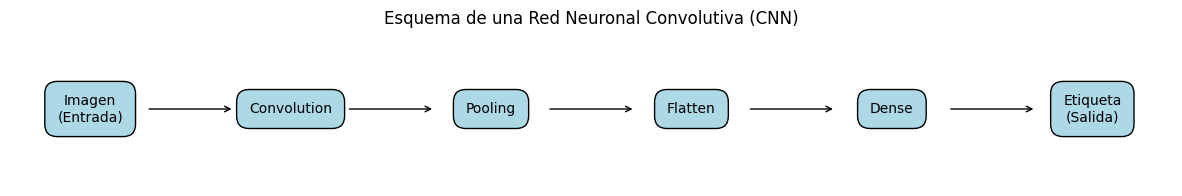

In [99]:
fig, ax = plt.subplots(figsize=(15, 2))
x_positions = [0, 2.5, 5, 7.5, 10, 12.5]
labels = ["Imagen\n(Entrada)", "Convolution", "Pooling", "Flatten", "Dense", "Etiqueta\n(Salida)"]
for x, label in zip(x_positions, labels):
    ax.text(x, 0.5, label,
            ha='center', va='center',
            bbox=dict(boxstyle="round,pad=0.9", edgecolor="black", facecolor='lightblue'))
for i in range(len(x_positions) -1):
    ax.annotate("",
                xy=(x_positions[i+1] - 0.7, 0.5),
                xytext=(x_positions[i] + 0.7, 0.5),
                arrowprops=dict(arrowstyle="->"))
ax.set_xlim(-1, 13.5)
ax.set_ylim(0, 1)
ax.axis('off')
plt.title("Esquema de una Red Neuronal Convolutiva (CNN)")
plt.show()

✍🏻 Las CNN son redes neuronales parte del sistema de sistema de **visión** computacional.

### 2. Implementación del modelo CNN para reconocimiento de imágenes
- Utilizando el dataset digitos_mnist_simple.csv, construye un modelo CNN con Keras para clasificar los dígitos del 0 al 9.
- Debes procesar los datos (reshape, normalización), definir y entrenar el modelo, mostrar métricas como accuracy, loss, y la matriz de confusión. Incluye el código explicado en el documento.

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, InputLayer
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import os
import random
import tensorflow as tf

In [101]:
semilla = 17
os.environ['PYTHONHASHSEED'] = str(semilla)
random.seed(semilla)
np.random.seed(semilla)
tf.random.set_seed(semilla)

✍ Se carga el dataset

In [102]:
df=pd.read_excel("/content/07. Apoyo desafío - digitos_mnist_simple.xlsx")

✍ Se analiza la estructura del dataset:

In [103]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,label
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       1797 non-null   float64
 1   1       1797 non-null   float64
 2   2       1797 non-null   float64
 3   3       1797 non-null   float64
 4   4       1797 non-null   float64
 5   5       1797 non-null   float64
 6   6       1797 non-null   float64
 7   7       1797 non-null   float64
 8   8       1797 non-null   float64
 9   9       1797 non-null   float64
 10  10      1797 non-null   float64
 11  11      1797 non-null   float64
 12  12      1797 non-null   float64
 13  13      1797 non-null   float64
 14  14      1797 non-null   float64
 15  15      1797 non-null   float64
 16  16      1797 non-null   float64
 17  17      1797 non-null   float64
 18  18      1797 non-null   float64
 19  19      1797 non-null   float64
 20  20      1797 non-null   float64
 21  21      1797 non-null   float64
 22  

In [105]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,label
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496,4.490818
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122,2.865304
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000,2.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000,4.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000,7.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,9.000000


In [106]:
df.isnull().values.any()

np.False_

✍ El dataset no posee valores nulos, posee 65 columnas, de las cuales 1 es la etiqueta (label) que va del 0 al 9, de tipo entero, y las otras 64 columnas son de tipo float. El dataset cuenta con 1797 filas.

✍ Considerando que se ha encomendado el desarrollo de un sistema que permita reconocer dígitos escritos a mano, a partir de imágenes en escala de grises, la interpretación del data set es el siguiente:
- Las 64 columnas float, son la representación de la imagen en escala de grises de los dígitos escritos a mano,
- La columna label, es el número representado en la imagen (etiqueta: 0 a 9).

✍ Más en detalle, son 64 columnas ya que se representan imagenes de 8x8 pixeles, donde cada fila es una imagen, cada columna es un pixel de los 64 totales (8x8), y el valor en el dataset es un número de 0 a 16, donde 0 es negro y 16 es blanco, y los valores intermedios son la escala de grises. A continuación se gráfica las imágenes de las 4 primeras filas:

In [107]:
X = df.drop("label",axis=1) #variables explicativas
Y = df["label"] # variable objetivo

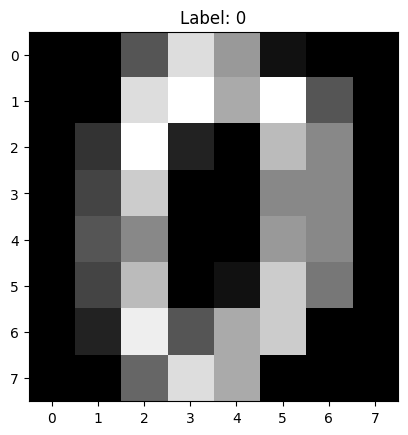

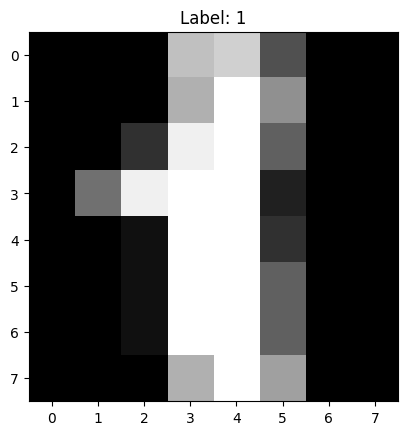

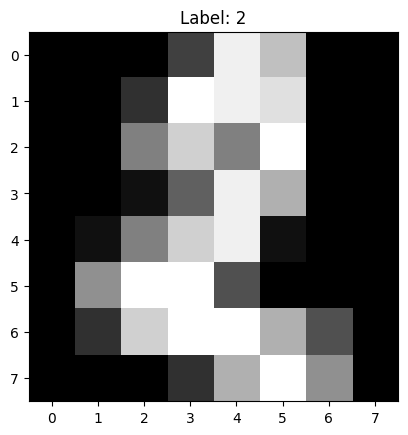

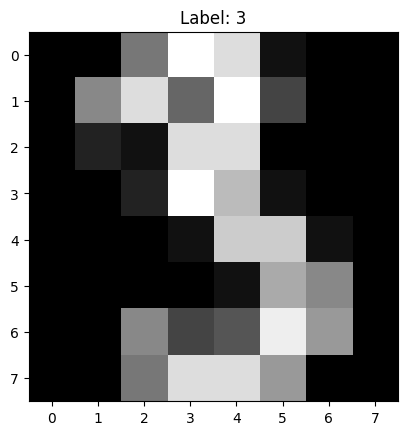

In [108]:
for linea in range(4):
  imagen = X.iloc[linea].values.reshape(8,8)
  plt.imshow(imagen,cmap="gray")
  plt.title(f"Label: {Y.iloc[linea]}")
  plt.show()

✍ Con objetivo de normalizar los valores, se divide por 16, que es el máximo posible. De esta manera los valores quedan de 0 a 1, escalados, lo que ayuda a tener un aprendizaje más controlado, rápido y convergente.

In [109]:
X = X/16.0

In [110]:
X.head()

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,0.3125,0.8125,0.5625,0.0625,0.0,0.0,0.0,0.0,...,0.0000,0.0,0.0,0.0,0.3750,0.8125,0.6250,0.0000,0.0000,0.0
1,0.0,0.0,0.0000,0.7500,0.8125,0.3125,0.0,0.0,0.0,0.0,...,0.0000,0.0,0.0,0.0,0.0000,0.6875,1.0000,0.6250,0.0000,0.0
2,0.0,0.0,0.0000,0.2500,0.9375,0.7500,0.0,0.0,0.0,0.0,...,0.3125,0.0,0.0,0.0,0.0000,0.1875,0.6875,1.0000,0.5625,0.0
3,0.0,0.0,0.4375,0.9375,0.8125,0.0625,0.0,0.0,0.0,0.5,...,0.5625,0.0,0.0,0.0,0.4375,0.8125,0.8125,0.5625,0.0000,0.0
4,0.0,0.0,0.0000,0.0625,0.6875,0.0000,0.0,0.0,0.0,0.0,...,0.0000,0.0,0.0,0.0,0.0000,0.1250,1.0000,0.2500,0.0000,0.0


✍ Luego es necesario redimensionar, en una matriz de 8x8. De manera que la CNN pueda reconocer la forma y bordes de la imagen.

In [111]:
X = X.values.reshape(-1,8,8,1)
# Se convierte en array de forma (8,8), para todas las filas (-1) y en escala de grises (1 color)

✍ Ahora se separa el dataset, en grupo de entrenamiento y grupo de validación. El tamaño de validacion/test sera de un 20%.

In [112]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=17)

✍ Ahora se define la red neuronal CNN:

In [113]:
modelo = Sequential() # se inician las capas

✍ 1. Se define la forma y colores de la imagen de entrada:

In [114]:
#Forma: de la entrada, imagen 8x8 pixeles en escala de grises
modelo.add(InputLayer(shape=(8, 8, 1)))

✍ 2. Se define la capa de convolución, la que recorre la imagen para detectar patrones. Aplicará 16 filtros de tamaño 3x3, por lo que se obtendrá un mapa de características de tamaño 6x6.

Nota: se usa ReLu para agregar no linealidad y poder encontrar patrones complejos.

In [115]:
# Convolución:
modelo.add(Conv2D(16, (3, 3), activation='relu'))

✍ 3. Ahora se aplica Pooling para reducir dimensionalidad del mapa de características obtenido en Conv2D, para evitar posibles sobreajustes y mejora en la eficiencia. Se usa MaxPolling en bloques de 2x2, para buscar el valor mas alto de cada bloque, reduciendo la dimensionalidad a la mitad: 3x3.

In [116]:
#Pooling
modelo.add(MaxPooling2D(pool_size=(2, 2)))

✍ 4. Luego, con el objetivo de que la información pueda ser leída por la capa Dense (capa siguiente), se aplana el resultado obtenido en la capa Pooling, usando Flatten, pasando de 2D a 1D (un vector)

In [117]:
# Flatten
modelo.add(Flatten())

✍ 5. Ahora se utiliza la capa Dense, que toma la salida anterior, para "aprender" y realizar una clasificación, usando la estructura de un perceptrón o neurona. La primera capa de Dense, tendrá 32 neuronas con no linealidad gracias a ReLu. La decisión de definir 32 neuronas va en relación a:
- la eficiencia computacional
- la simplicidad del modelo (detección números en escala de grises)
- no muy grande para evitar sobreajuste y complejidad del modelo innecesaria.
- no muy pequeño para permitir aprendizaje

In [118]:
# Dense
modelo.add(Dense(32, activation='relu'))

✍ 6. Para la capa de salida, tambien se utiliza una capa Dense, que recibirá una entrada de dimension 32 y obtendrá una salida de dimensión 10, considerando que los posibles labels son 10 (digitos de 0 a 9). La interpretación entonces de la salida, será un listado de de 10 probabilidades para cada digito posible.
Nota: Se utiliza softmax, para que las probabilidades sumen 1.

In [119]:
#Salida
modelo.add(Dense(10, activation='softmax'))

✍ Ahora definido el modelo, toca la compilación de este, es decir, toca definir la manera en que se va aprender, como se medirá el error y como se evaluarán los resultados:

- En este caso se usa el optimizador "adam", para ir ajustando los pesos en el entrenamiento (usa el error, calcula gradientes y ajusta pesos)

- Se utiliza función de perdida "sparse_categorical_crossentropy", para medir que tan equivocada está o no la red neuronal, ya que es una claficación de múltilples clases con etiquetas (no one hot)

- Y la métrica de evaulación del modelo será "accuracy", que medirá el porcentaje de aciertos.

In [120]:
modelo.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

✍ Ahora corresponde el entrenamiento del modelo, usando fit para que el modelo aprenda de los datos, bajo la lógica:
- Forward pass: predicción
- Loss: cálculo del error
- Backpropagation: ajuste de pesos
- Iteración: y repetición

✍ Se definen 20 iteraciones para obtener un resultado robusto:

In [121]:
entrenamiento_20= modelo.fit(
    X_train,
    Y_train,
    epochs=20,
    validation_data=(X_test, Y_test)
)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3633 - loss: 2.2020 - val_accuracy: 0.5417 - val_loss: 2.0906
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6590 - loss: 1.8896 - val_accuracy: 0.7028 - val_loss: 1.6518
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8260 - loss: 1.3324 - val_accuracy: 0.8778 - val_loss: 1.0320
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8949 - loss: 0.7875 - val_accuracy: 0.9167 - val_loss: 0.6178
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9179 - loss: 0.4945 - val_accuracy: 0.9250 - val_loss: 0.4249
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9297 - loss: 0.3579 - val_accuracy: 0.9417 - val_loss: 0.3301
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9395 - loss: 0.2845 - val_accuracy: 0.9472 - val_loss: 0.2737
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9464 - loss: 0.2374 - val_accuracy: 0.9556 - val_loss

✍🏻 Con un resultado final de validación de:

In [122]:
loss,accuracy = modelo.evaluate(X_test,Y_test)
print("Accuracy: ",accuracy)
print("Loss: ",loss)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9750 - loss: 0.1035 
Accuracy:  0.9750000238418579
Loss:  0.10346802324056625


✍🏻 Al observar los resultados se obtiene:
- En entrenamiento: Accuracy: 0.98 | Loss: 0.08
- En test: Accuracy: 0.975 | Loss 0.1

 ✍🏻 Y se grafica el accuracy y loss para mejor entendimiento de como varía a lo largo de las épocas o interaciones del aprendizaje:

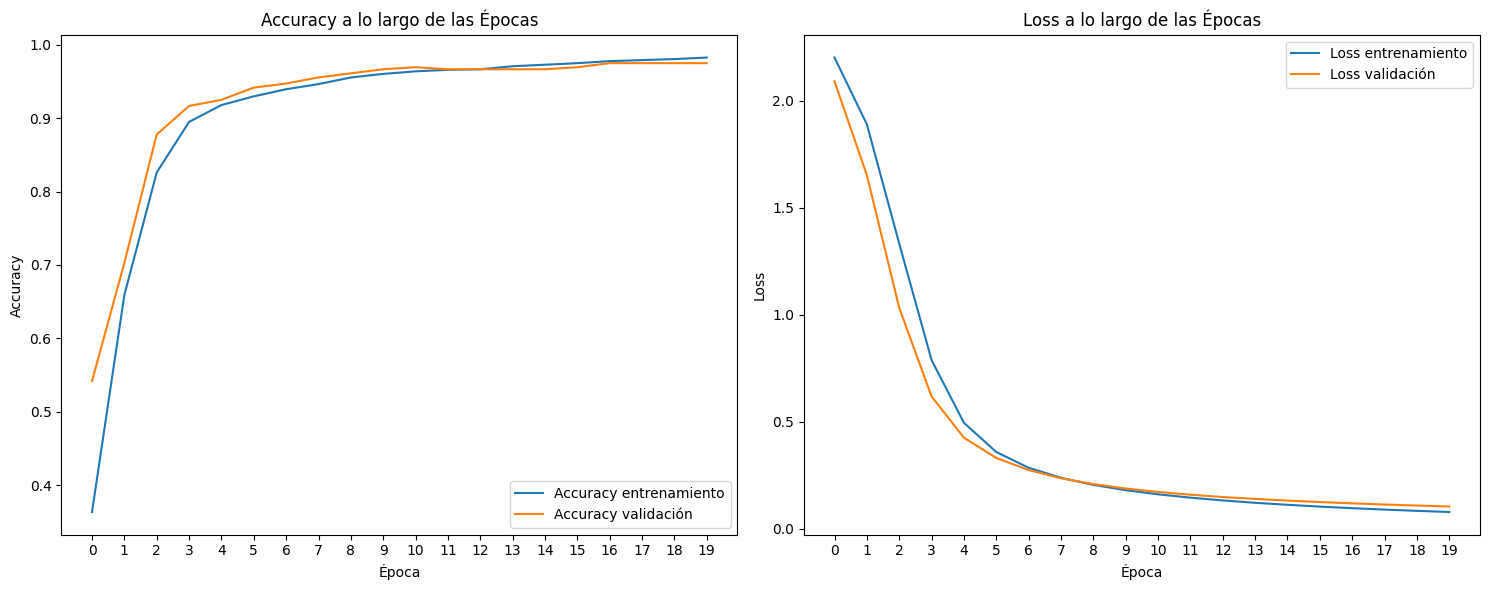

In [123]:
plt.figure(figsize=(15, 6)) # se genera la figura

plt.subplot(1, 2, 1) # se define el primer grafico
plt.plot(entrenamiento_20.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(entrenamiento_20.history['val_accuracy'], label='Accuracy validación')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Accuracy a lo largo de las Épocas')
plt.xticks(np.arange(0, len(entrenamiento_20.history['accuracy']), 1)) # Se ajusta las etiquetas del eje x
plt.legend()

plt.subplot(1, 2, 2) #  se define el segundo grafico
plt.plot(entrenamiento_20.history['loss'], label='Loss entrenamiento')
plt.plot(entrenamiento_20.history['val_loss'], label='Loss validación')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Loss a lo largo de las Épocas')
plt.xticks(np.arange(0, len(entrenamiento_20.history['loss']), 1)) # Se ajusta las etiquetas del eje x
plt.legend()


plt.tight_layout() # para evitar superposición
plt.show()

 ✍🏻 Se puede observan entonces que el **accuracy**, tanto en entrenamiento como en validación va aumentando a medida que se va avanzando en las iteraciones, demostrando el aprendizaje que se va logrando al ser cada vez más preciso en coincidir con el resultado esperado. Logrando un accuracy final en validación de 0.975, lo que implica que el modelo final logra predecir el 97.5% de los casos de manera correcta.


✍🏻 Del mismo modo se observa el aprendizaje del modelo al observar el **loss** (función de pérdida) que va disminuyendo a medida que el modelo avanza en las iteraciones, tanto en entrenamiento como en validación. Esto siginifica que cada vez el modelo obtiene menos error en su predicción. Se considera que un loss menor a 0.2 es muy bueno, y en este caso se obtiene un muy buen resultado con un loss en validación de 0.1, lo que indica buena confianza en la predicción.

✍🏻 Corresponde analizar también si existe o no, overfitting o underfitting, pero dado que el accuracy, tanto de train como de test son altos, y el loss, tanto de train como de test son bajos, se puede considerar que es un **buen modelo**, que no esta sobreajustado (es decir, no memoriza los datos de train), y tampoco esta subajustado (ya que el modelo aprende bien y predice bien).

 ✍🏻 Ahora se analiza la matriz de confusión para visualizar en donde se ubican los errores del modelo (que son menores ya que se tiene un accuracy de 97.5%):

In [124]:
Y_pred = modelo.predict(X_test)
Y_pred = np.argmax(Y_pred, axis=1)

matriz_confusion = confusion_matrix(Y_test, Y_pred)
print(matriz_confusion)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
[[34  0  0  0  0  0  0  0  0  0]
 [ 0 33  0  0  0  1  0  0  0  0]
 [ 0  0 34  0  0  0  0  0  0  0]
 [ 0  0  0 36  0  1  0  1  0  0]
 [ 1  0  0  0 38  0  0  0  1  0]
 [ 0  0  0  0  0 40  0  0  0  1]
 [ 0  0  0  0  0  0 31  0  1  0]
 [ 0  0  0  0  0  0  0 31  0  0]
 [ 0  0  0  0  0  0  0  0 36  0]
 [ 0  0  0  0  1  0  0  0  1 38]]


 ✍🏻Se grafica como mapa de calor para facilidad en la interpretación

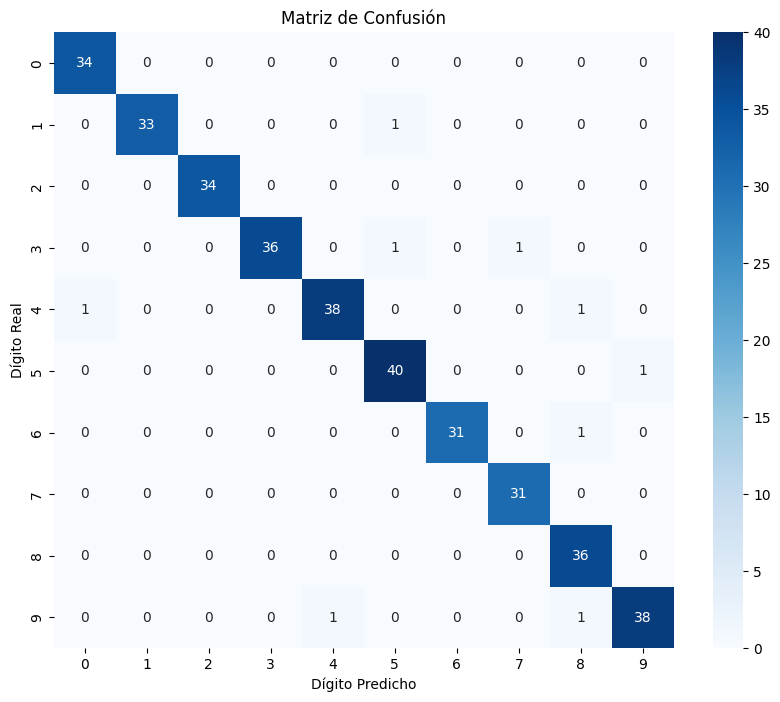

In [125]:
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.xlabel('Dígito Predicho')
plt.ylabel('Dígito Real')
plt.title('Matriz de Confusión')
plt.show()

✍🏻 Como es de esperar, la diagonal de la matriz de confusión tiene la mayor concentración de casos, lo que implica que la mayor parte de los digitos predichos (es decir, el dígito que el modelo interpretó al analizar la imagen) es congruente con el digito real (etiqueta).

Luego, los casos que están fuera de la diagonal son los casos en que el modelo predijo un digito diferente al real. Y que de hecho son casos puntuales:
- Un digito 4, que el modelo pensó que era un 0.
- Un digito 9, que el modelo pensó que era un 4.
- Digitos 1 y 3, que el modelo pensó que eran un 5.
- Un digito 3, que el modelo pensó que era un 7.
- Dígitos 4, 6 y 9, que el modelo pensó que eran un 8.
- Un dígito 5, que el modelo pensó que era un 9.

Estos 9 casos representan el 2.5% del dataset de validación (test) que no fue predicho correctamente, es decir, una parte no siginificativa.

✍🏻 En conslusión, el modelo entrenado logra muy buenos resultados en la predicción de digitos escritos a mano en escala de grises, logrando un acierto en el 97.5% de los casos (con datos de test).

### 3. Evaluación y optimización del modelo
- Describe y aplica al menos dos técnicas de mejora del desempeño del modelo: ajuste de hiperparámetros (épocas, batch size, optimizador) y regularización (Dropout, EarlyStopping, etc.).
- Muestra los resultados y reflexiona sobre su impacto.

✍🏻 Ahora corresponde ir en búsqueda de la optimización del modelo, y las alternativas que se evaluan son:

- Ajustar hiperparámetro **épocas**: que modifica la cantidad de veces que el modelo intera sobre el dataset. Pocas épocas pueden generar underfitting y muchas épocas pueden generar overfitting.
- Ajustar hiperparámetro **batch size**: que modifica el número de muestras procesadas en cada época del entrenamiento del modelo. Por defecto se usa 32 muestras. Pero si se observa que el entrenamiento es muy lento, se recomienda subir la cantidad. Y si se observa un entrenamiento intestable, se recomienda disminuir. *Nota: en este caso no se observa un entrenamiento ni muy lento ni inestable*
- Ajustar hiperparámetro **optimizador**: que modifica el algoritmo que ajusta los pesos en el entrenamiento. Se utilizó "adam" que se considera eficiente, pero existe también "sgd" que es más simple, y "rmsprop" que sirve para modelos más complejos. Este hiperparámetro debería ser modificado si el modelo no logra buena convergencia.*Nota: en este caso si se logra convergencia con adam*
- Ajustar regularización con **Dropuot**: que define que parte de las neuronas del modelo apagar durante el entrenamiento para evitar overfitting.
- Ajustar regularización con **EarlyStopping**: que detiene el entrenamiento cuando deja de mejorar el modelo (es específico cuando el loss de test ya no mejora), lo que evita overfitting y ahorra tiempo.
- Ajustar la **cantidad de neuronas** de aprendizaje en la capa Dense: aumentarlas hace un modelo mas complejo, pero con riesgo de sobreajustar.

✍🏻 Si bien el modelo tiene un buen desempeño por lo que no es estrictamente necesario las modificaciones, de todas maneras se aplicará una optimización, a través de:
- Ajuste de hiperparámetro épocas
- Ajuste regularización con EarlyStopping
- Ajuste regularización con DropOut
- Ajuste de cantidad de neuronas

Ya que la modificación de iteraciones pueden mejorar el desempeño del modelo, EarlyStopping evita el sobrentrenamiento y mejora la generalización, DropOut previene el sobreajuste y también mejora la generalización, y el aumento de la cantidad de neuronas genera un modelo más complejo y robusto.

✍🏻 Se define entonces el modelo optimizado:

Entrenamiento:
Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3076 - loss: 2.1968 - val_accuracy: 0.5722 - val_loss: 2.0298
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6026 - loss: 1.7670 - val_accuracy: 0.7806 - val_loss: 1.4605
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7397 - loss: 1.1812 - val_accuracy: 0.8611 - val_loss: 0.8680
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8024 - loss: 0.7867 - val_accuracy: 0.9389 - val_loss: 0.5539
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8713 - loss: 0.5455 - val_accuracy: 0.9472 - val_loss: 0.4045
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8838 - loss: 0.4530 - val_accuracy: 0.9556 - val_loss: 0.3243
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8907 - loss: 0.3765 - val_accuracy: 0.9611 - val_loss: 0.2689
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9040 - loss: 0.3283 - val_accuracy: 0.9

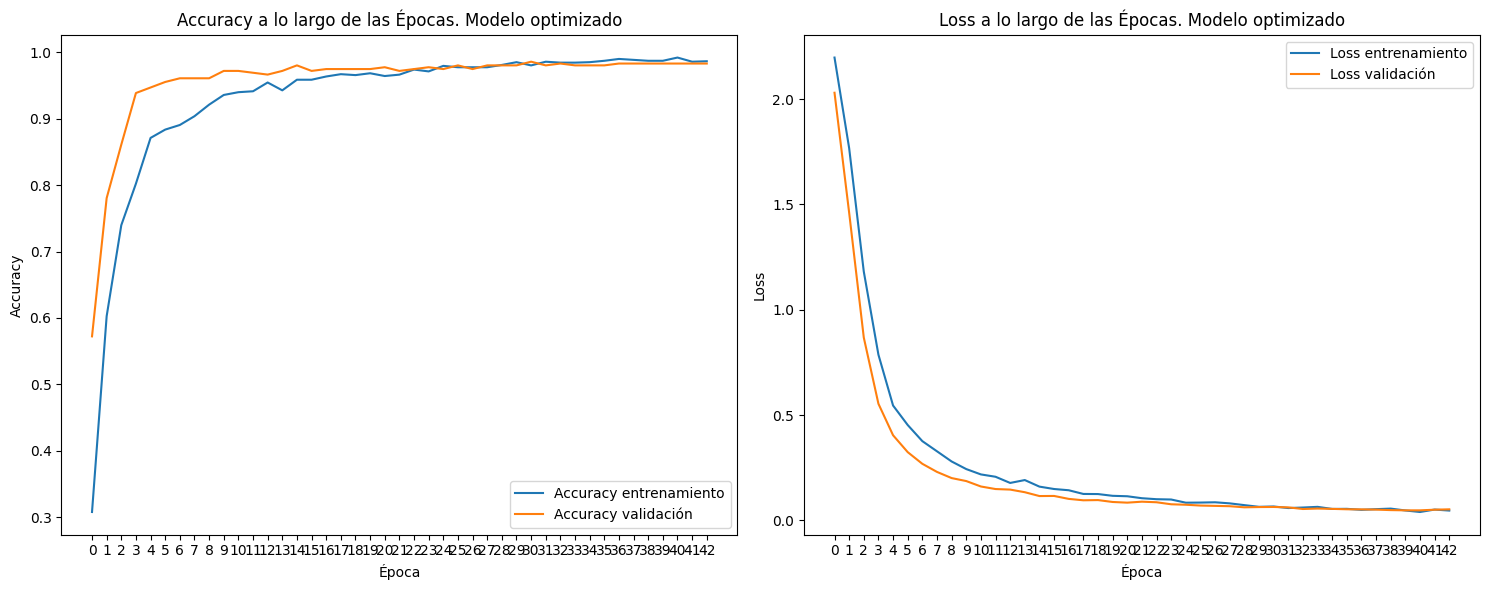

Matriz de confusión
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
[[34  0  0  0  0  0  0  0  0  0]
 [ 0 34  0  0  0  0  0  0  0  0]
 [ 0  0 34  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  1  0  0]
 [ 0  0  0  0 40  0  0  0  0  0]
 [ 0  0  0  0  0 40  0  0  0  1]
 [ 0  0  0  0  0  0 32  0  0  0]
 [ 0  0  0  0  0  0  0 31  0  0]
 [ 0  1  0  0  0  0  0  1 34  0]
 [ 0  0  0  0  1  1  0  0  0 38]]


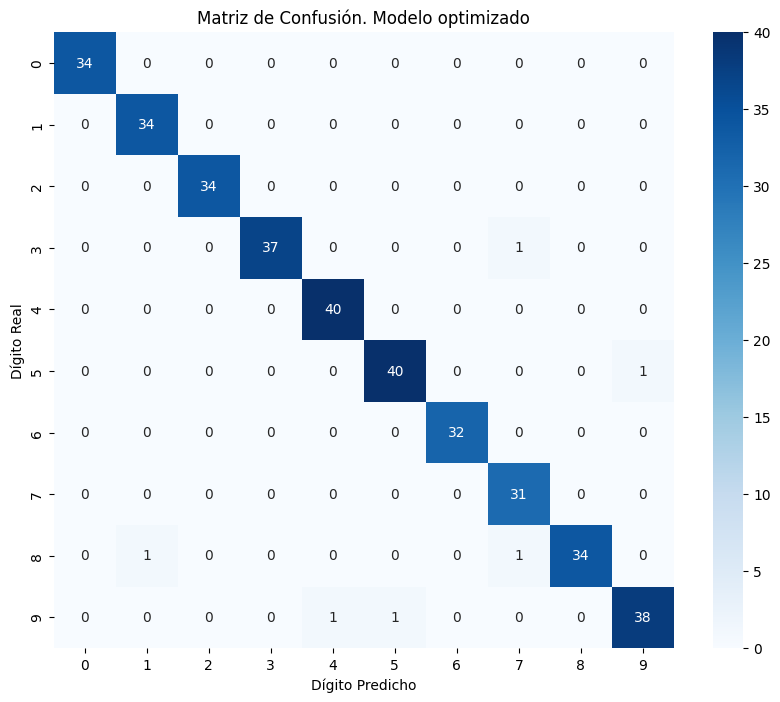

In [126]:
#OPTIMIZACIÓN: se agrega el EarlyStopping
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Se mantiene resto del modelo
modelo_optimizado = Sequential()
modelo_optimizado.add(InputLayer(shape=(8, 8, 1)))
modelo_optimizado.add(Conv2D(16, (3, 3), activation='relu'))
modelo_optimizado.add(MaxPooling2D(pool_size=(2, 2)))
modelo_optimizado.add(Flatten())

#OPTIMIZACIÓN: se agrega el DropOut para la capa Dense intermedia, y se aumenta la cantidad de neuronas a 64
modelo_optimizado.add(Dense(64, activation='relu'))
modelo_optimizado.add(tf.keras.layers.Dropout(0.3))

# Se mantiene la salida del modelo y la compilación
modelo_optimizado.add(Dense(10, activation='softmax'))
modelo_optimizado.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# OPTIMIZACIÓN: se aumenta la cantidad de épocas a 50 (no hay problema si son demasiadas porque EarlyStop detendrá el entrenamiento si es necesario)
print("Entrenamiento:")
entrenamiento_40= modelo_optimizado.fit(X_train, Y_train,
                                        epochs=50, # aumento de épocas
                                        validation_data=(X_test, Y_test),
                                        callbacks=[early_stop] # se agrega earlystopping
                                        )

# Se mantiene la evaluación del modelo
loss_optimizado,accuracy_optimizado = modelo_optimizado.evaluate(X_test,Y_test)
print("Evaluación")
print("Accuracy modelo optimizado: ",accuracy_optimizado)
print("Loss modelo optimizado: ",loss_optimizado)

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.plot(entrenamiento_40.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(entrenamiento_40.history['val_accuracy'], label='Accuracy validación')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Accuracy a lo largo de las Épocas. Modelo optimizado')
plt.xticks(np.arange(0, len(entrenamiento_40.history['accuracy']), 1))
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(entrenamiento_40.history['loss'], label='Loss entrenamiento')
plt.plot(entrenamiento_40.history['val_loss'], label='Loss validación')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Loss a lo largo de las Épocas. Modelo optimizado')
plt.xticks(np.arange(0, len(entrenamiento_40.history['loss']), 1))
plt.legend()
plt.tight_layout()
plt.show() # aqui

print("Matriz de confusión")
Y_pred = modelo_optimizado.predict(X_test)
Y_pred = np.argmax(Y_pred, axis=1)
matriz_confusion_optimizado = confusion_matrix(Y_test, Y_pred)
print(matriz_confusion_optimizado)

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_confusion_optimizado, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.xlabel('Dígito Predicho')
plt.ylabel('Dígito Real')
plt.title('Matriz de Confusión. Modelo optimizado')
plt.show()

 ✍🏻 Luego de aplicar las optimizaciones:
 - Aumento de cantidad de épocas a 50
 - EarlyStopping, para que se detenga cuando encuentre mejor valor de loss *(el entrenamiento se detuvo en la época 43, ya que en la época 40 ya se logró el mejor valor de loss).*
 - DropOut para agregar variabilidad, apagando aleatoriamente el 30% de las neuronas cada vez.
 - Aumento de la cantidad de neuronas a 64 (antes eran 32).

  ✍🏻 Se logra obtener un modelo optimizado, que logra mejores resultados que el modelo base lo que se aprecia en:
 - Un Accuracy mayor de 98.1% (respecto al anterior de 97.5%), lo que indica un acierto en el 98.3% de los casos.
 - Un Loss menor de 0.05 (respecto al anterior de 0.1), lo que indica un menor error en las predicciones.
 - Los valores de loss y accuracy en test son similares a los obtenidos en entrenamiento. Esto es una buena señal ya que indica que el modelo no "memorizó" los datos de entrenamiento, y logra la capacidad de generalizar la prediccion, obteniendo buenos resultados en el dataset de validación.
- Considerando lo anterior, se descarta underfitting y overfitting, lo que es bueno.
- La matriz de confusión muestra buenos resultados, con una diagonal potente, y menores casos de error (con 6 casos respecto a los 9 casos del modelo base)

✍🏻 En resumen, con las optimizaciones aplicadas, se obtiene un mejor modelo, que predice de mejor manera.